# Module 1 — Neural Chain Ladder

> **Pedagogical goal:** Show that the classical Chain Ladder is a special case of a neural network — specifically, a single-layer linear network with no bias and no activation function. Then extend it.

---

## Outline

1. [Load data](#1-load-data)
2. [Classical Chain Ladder](#2-classical-chain-ladder)
3. [Chain Ladder as a Neural Network](#3-chain-ladder-as-a-neural-network)
4. [The Equivalence](#4-the-equivalence)
5. [Extended Neural Chain Ladder](#5-extended-neural-chain-ladder)
6. [Comparison](#6-comparison)

---
## 0. Imports

In [79]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

sys.path.insert(0, "..")
from src.data.data_loader import load_company, list_companies, load_line

DATA_DIR = Path("../data/cas_schedule_p/raw")
torch.manual_seed(42)
np.random.seed(42)

---
## 1. Load Data

We work with Private Passenger Auto (`ppauto`). We pick one company to start — the classical CL is company-by-company.

In [80]:
# See the first 20 available companies in ppauto
df = load_line("ppauto", data_dir=DATA_DIR)
list_companies(df).head(20)

,GRCODE,GRNAME,n_rows
0,43,IDS Property Cas Ins Co,100
1,266,Public Underwriters Grp,100
2,353,Celina Mut Grp,100
3,388,Federal Ins Co Grp,100
4,460,Buckeye Ins Grp,100
5,620,Employers Mut Co Of Des Moines,100
6,671,Farm Bureau Of MI Grp,100
7,692,Wawanesa Ins Grp,100
8,715,West Bend Mut Ins Grp,100
9,965,Secura Ins Co,100


In [81]:
# Load one company — change grcode to explore others
GRCODE = df["GRCODE"].iloc[0]   # first company in the file
# GRCODE = 266                  # second company
result = load_company("ppauto", grcode=GRCODE, data_dir=DATA_DIR)

print(f"Company : {result['grname']}")
print(f"GRCODE  : {result['grcode']}")
print()
print("Upper triangle of Cumulative Paid Loss (training data):")
result["upper"]

Company : IDS Property Cas Ins Co
GRCODE  : 43

Upper triangle of Cumulative Paid Loss (training data):


DevelopmentLag,1,2,3,4,5,6,7,8,9,10
AccidentYear,,,,,,,,,,
1988,133.0,333.0,431.0,570.0,615.0,615.0,615.0,614.0,614.0,614.0
1989,934.0,1746.0,2365.0,2579.0,2763.0,2966.0,2940.0,2978.0,2978.0,NaN
1990,2030.0,4864.0,6880.0,8087.0,8595.0,8743.0,8763.0,8762.0,NaN,NaN
1991,4537.0,11527.0,15123.0,16656.0,17321.0,18076.0,18308.0,NaN,NaN,NaN
1992,7564.0,16061.0,22465.0,25204.0,26517.0,27124.0,NaN,NaN,NaN,NaN
1993,8343.0,19900.0,26732.0,30079.0,31249.0,NaN,NaN,NaN,NaN,NaN
1994,12565.0,26922.0,33867.0,38338.0,NaN,NaN,NaN,NaN,NaN,NaN
1995,13437.0,26012.0,31677.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1996,12604.0,23446.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [82]:
print("Lower triangle (ground truth — actual future paid losses):")
result["lower"]

Lower triangle (ground truth — actual future paid losses):


DevelopmentLag,1,2,3,4,5,6,7,8,9,10
AccidentYear,,,,,,,,,,
1988,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1989,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2938.0
1990,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8729.0,8802.0
1991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18602.0,18434.0,18464.0
1992,NaN,NaN,NaN,NaN,NaN,NaN,27191.0,27680.0,27645.0,27662.0
1993,NaN,NaN,NaN,NaN,NaN,31907.0,31989.0,32451.0,32540.0,32531.0
1994,NaN,NaN,NaN,NaN,40113.0,41520.0,42031.0,42104.0,42187.0,42215.0
1995,NaN,NaN,NaN,34795.0,36841.0,38155.0,38776.0,38850.0,39088.0,39140.0
1996,NaN,NaN,28277.0,31552.0,33599.0,34689.0,35236.0,35295.0,35315.0,35328.0


---
## 2. Classical Chain Ladder

The Chain Ladder method estimates **age-to-age development factors** (link ratios) from the upper triangle:

$$f_k = \frac{\sum_{i} C_{i,k+1}}{\sum_{i} C_{i,k}}$$

where $C_{i,k}$ is cumulative paid losses for accident year $i$ at development lag $k$, and the sum runs over all accident years where both $C_{i,k}$ and $C_{i,k+1}$ are known (i.e. in the upper triangle).

Ultimates are then projected by applying the factors to the latest diagonal.

In [ ]:
def chain_ladder_factors(upper: pd.DataFrame) -> pd.Series:
    """
    Compute volume-weighted age-to-age development factors from the upper triangle.
    Returns a Series indexed by the 'from' lag (1 -> 2, 2 -> 3, ...).
    """
    lags = sorted(upper.columns)
    factors = {}

    for i in range(len(lags) - 1):
        k     = lags[i]
        k1    = lags[i + 1]
        # Only rows where both C_{i,k} and C_{i,k+1} are known, therefore only the upper triangle
        mask  = upper[k].notna() & upper[k1].notna()
        num   = upper.loc[mask, k1].sum()
        denom = upper.loc[mask, k].sum()
        factors[k] = num / denom

    return pd.Series(factors, name="link_ratio")


factors = chain_ladder_factors(result["upper"])
print("Age-to-age development factors:")
factors

In [83]:
def chain_ladder_project(upper: pd.DataFrame, factors: pd.Series) -> pd.DataFrame:
    """
    Project the full square from the upper triangle and link ratios.
    Returns a DataFrame with the same shape as upper, with lower cells filled in.
    """
    projected = upper.copy().astype(float)
    lags = sorted(upper.columns)

    for ay in projected.index:
        for i, lag in enumerate(lags[:-1]): # We skip the last because there's no "next lag" to project into.
            next_lag = lags[i + 1]
            if pd.isna(projected.loc[ay, next_lag]) and pd.notna(projected.loc[ay, lag]): # Assure the next cell is empty, and the one from which we are projecting is not NaN
                projected.loc[ay, next_lag] = projected.loc[ay, lag] * factors[lag]

    return projected


cl_projected = chain_ladder_project(result["upper"], factors)
print("Projected square (CL):")
round(cl_projected, 2)

Projected square (CL):


DevelopmentLag,1,2,3,4,5,6,7,8,9,10
AccidentYear,,,,,,,,,,
1988,133.0,333.00,431.00,570.00,615.00,615.00,615.00,614.00,614.00,614.00
1989,934.0,1746.00,2365.00,2579.00,2763.00,2966.00,2940.00,2978.00,2978.00,2978.00
1990,2030.0,4864.00,6880.00,8087.00,8595.00,8743.00,8763.00,8762.00,8762.00,8762.00
1991,4537.0,11527.00,15123.00,16656.00,17321.00,18076.00,18308.00,18361.51,18361.51,18361.51
1992,7564.0,16061.00,22465.00,25204.00,26517.00,27124.00,27325.65,27405.51,27405.51,27405.51
1993,8343.0,19900.00,26732.00,30079.00,31249.00,32208.12,32447.56,32542.39,32542.39,32542.39
1994,12565.0,26922.00,33867.00,38338.00,40128.72,41360.39,41667.87,41789.64,41789.64,41789.64
1995,13437.0,26012.00,31677.00,35685.71,37352.54,38499.00,38785.21,38898.56,38898.56,38898.56
1996,12604.0,23446.00,30472.27,34328.51,35931.96,37034.81,37310.13,37419.18,37419.18,37419.18


In [84]:
def style_triangle(projected: pd.DataFrame, upper: pd.DataFrame):
    """
    Display the projected triangle with known cells normal and projected cells in italic blue.
    """
    styles = pd.DataFrame("", index=projected.index, columns=projected.columns)
    for ay in projected.index:
        for lag in projected.columns:
            if pd.isna(upper.loc[ay, lag]) and pd.notna(projected.loc[ay, lag]):
                styles.loc[ay, lag] = "font-style: italic; color: steelblue;"
    return projected.style.apply(lambda _: styles, axis=None).format("{:,.0f}")


style_triangle(cl_projected, result["upper"])

DevelopmentLag,1,2,3,4,5,6,7,8,9,10
AccidentYear,,,,,,,,,,
1988,133,333,431,570,615,615,615,614,614,614
1989,934,"1,746","2,365","2,579","2,763","2,966","2,940","2,978","2,978","2,978"
1990,"2,030","4,864","6,880","8,087","8,595","8,743","8,763","8,762","8,762","8,762"
1991,"4,537","11,527","15,123","16,656","17,321","18,076","18,308","18,362","18,362","18,362"
1992,"7,564","16,061","22,465","25,204","26,517","27,124","27,326","27,406","27,406","27,406"
1993,"8,343","19,900","26,732","30,079","31,249","32,208","32,448","32,542","32,542","32,542"
1994,"12,565","26,922","33,867","38,338","40,129","41,360","41,668","41,790","41,790","41,790"
1995,"13,437","26,012","31,677","35,686","37,353","38,499","38,785","38,899","38,899","38,899"
1996,"12,604","23,446","30,472","34,329","35,932","37,035","37,310","37,419","37,419","37,419"


In [85]:
def evaluate(projected: pd.DataFrame, actual: pd.DataFrame) -> pd.DataFrame:
    """
    Compare projected vs actual lower triangle.
    Returns a summary with projected ultimate, actual ultimate, and % error.
    """
    lags = sorted(projected.columns)
    last_lag = lags[-1]

    summary = pd.DataFrame({
        "Projected Ultimate" : projected[last_lag],
        "Actual Ultimate"    : actual[last_lag],
    })
    summary["Error %"] = (
        (summary["Projected Ultimate"] - summary["Actual Ultimate"])
        / summary["Actual Ultimate"] * 100
    ).round(2)
    return round(summary.dropna(), 2)


cl_eval = evaluate(cl_projected, result["lower"])
cl_eval

,Projected Ultimate,Actual Ultimate,Error %
AccidentYear,,,
1989,2978.00,2938.0,1.36
1990,8762.00,8802.0,-0.45
1991,18361.51,18464.0,-0.56
1992,27405.51,27662.0,-0.93
1993,32542.39,32531.0,0.04
1994,41789.64,42215.0,-1.01
1995,38898.56,39140.0,-0.62
1996,37419.18,35328.0,5.92
1997,41292.59,37235.0,10.90


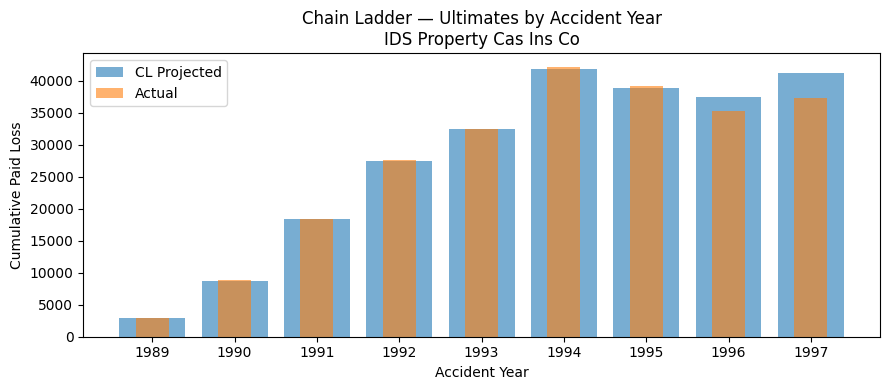

In [86]:
fig, ax = plt.subplots(figsize=(9, 4))
x = cl_eval.index.astype(str)
ax.bar(x, cl_eval["Projected Ultimate"], alpha=0.6, label="CL Projected")
ax.bar(x, cl_eval["Actual Ultimate"],    alpha=0.6, label="Actual", width=0.4)
ax.set_title(f"Chain Ladder — Ultimates by Accident Year\n{result['grname']}")
ax.set_xlabel("Accident Year")
ax.set_ylabel("Cumulative Paid Loss")
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Chain Ladder as a Neural Network

### The key insight

The volume-weighted link ratio from lag $k$ to $k+1$ is:

$$f_k = \frac{\sum_i C_{i,k+1}}{\sum_i C_{i,k}}$$

This is exactly the **OLS estimate** of the slope in a regression of $C_{i,k+1}$ on $C_{i,k}$ **with no intercept**:

$$C_{i,k+1} = w_k \cdot C_{i,k} + \varepsilon_i$$

And a regression with no intercept, one input, one output, and no activation function is exactly a **neural network with no hidden layers**.

So: **Chain Ladder ≡ a sequence of single-neuron linear networks, one per development lag.**

We train one network per lag transition (1→2, 2→3, ...) on the upper triangle data points.

**Each network sees only the data relevant to its transition.** For example:

- Network 1 is trained on $(C_{i,1}, C_{i,2})$ — it learns "given cumulative paid after 1 year, predict cumulative paid after 2 years"
- Network 2 is trained on $(C_{i,2}, C_{i,3})$ — it learns "given cumulative paid after 2 years, predict cumulative paid after 3 years"

In [87]:
def build_lag_pairs(upper: pd.DataFrame) -> dict[int, tuple]:
    """
    For each lag transition k -> k+1, extract (X, y) pairs from the upper triangle.
    X = C_{i,k}, y = C_{i,k+1}, both as float32 tensors of shape (n, 1).
    unsqueeze(1) converts the flat tensor [a, b, c] into a column [[a], [b], [c]]
    which is the shape nn.Linear expects: (batch_size, features).
    """
    lags = sorted(upper.columns)
    pairs = {}

    for i in range(len(lags) - 1):
        k, k1 = lags[i], lags[i + 1]
        mask  = upper[k].notna() & upper[k1].notna()
        X = torch.tensor(upper.loc[mask, k].values,  dtype=torch.float32).unsqueeze(1)
        y = torch.tensor(upper.loc[mask, k1].values, dtype=torch.float32).unsqueeze(1)
        pairs[k] = (X, y)

    return pairs


lag_pairs = build_lag_pairs(result["upper"])
print(f"Lag transitions available: {list(lag_pairs.keys())}")
print(f"Example (lag 1->2): X shape={lag_pairs[1][0].shape}, y shape={lag_pairs[1][1].shape}")

Lag transitions available: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Example (lag 1->2): X shape=torch.Size([9, 1]), y shape=torch.Size([9, 1])


In [90]:
class LinearNoBias(nn.Module):
    """
    Single-neuron linear network: y = w * x
    No bias, no activation — this is the neural equivalent of CL.
    """
    def __init__(self):
        super().__init__() # the __init__ class inherits from nn.Module of PyTorch, needed to initialize the nn.
        self.w = nn.Linear(in_features=1, out_features=1, bias=False)

    def forward(self, x):
        return self.w(x)


def train_single_lag(
    X: torch.Tensor,
    y: torch.Tensor,
    epochs: int = 2000,
    lr: float = 0.05,
) -> tuple[LinearNoBias, list]:
    """
    Train a LinearNoBias model on one lag transition.
    Returns the trained model and loss history.
    """
    # normalise by the mean of X so inputs are ~order 1
    scale = X.mean()
    X_scaled = X / scale
    y_scaled = y / scale

    model     = LinearNoBias()
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    losses    = []

    for _ in range(epochs):
        optimiser.zero_grad()           # initializing weights in every epoch
        loss = criterion(model(X_scaled), y_scaled)   # compute MSE loss
        loss.backward()                 # compute new gradients
        optimiser.step()                # update weights with the new gradients
        losses.append(loss.item())

    return model, losses


# Train one model per lag transition
nn_models  = {}
nn_weights = {}

for lag, (X, y) in lag_pairs.items():
    model, _ = train_single_lag(X, y)
    nn_models[lag]  = model
    nn_weights[lag] = model.w.weight.item()

nn_factors = pd.Series(nn_weights, name="nn_weight")
print("Neural network learned weights:")
nn_factors

Neural network learned weights:


1    2.054260
2    1.282389
3    1.126310
4    1.044434
5    1.028576
6    1.010407
7    1.001193
8    1.000000
9    1.000000
Name: nn_weight, dtype: float64

---
## 4. The Equivalence

If the equivalence holds, the learned weights should match the classical CL link ratios almost exactly.

In [91]:
comparison = pd.DataFrame({
    "CL Link Ratio" : factors,
    "NN Weight"     : nn_factors,
})
comparison["Difference"] = (comparison["NN Weight"] - comparison["CL Link Ratio"]).abs()
comparison["Diff %"]     = (comparison["Difference"] / comparison["CL Link Ratio"] * 100).round(4)
print("CL vs NN — weight comparison:")
comparison

CL vs NN — weight comparison:


,CL Link Ratio,NN Weight,Difference,Diff %
1,2.104864,2.054260,0.050604,2.4041
2,1.299679,1.282389,0.017289,1.3303
3,1.126549,1.126310,0.000240,0.0213
4,1.046709,1.044434,0.002275,0.2174
5,1.030693,1.028576,0.002117,0.2054
6,1.007434,1.010407,0.002973,0.2951
7,1.002923,1.001193,0.001730,0.1725
8,1.000000,1.000000,0.000000,0.0000
9,1.000000,1.000000,0.000000,0.0000


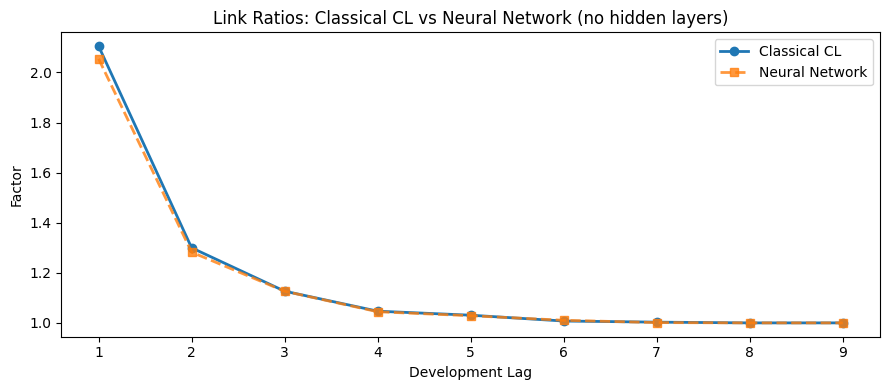

In [92]:
fig, ax = plt.subplots(figsize=(9, 4))
x = comparison.index.astype(str)
ax.plot(x, comparison["CL Link Ratio"], "o-",  label="Classical CL",  linewidth=2)
ax.plot(x, comparison["NN Weight"],     "s--",  label="Neural Network", linewidth=2, alpha=0.8)
ax.set_title("Link Ratios: Classical CL vs Neural Network (no hidden layers)")
ax.set_xlabel("Development Lag")
ax.set_ylabel("Factor")
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Extended Neural Chain Ladder

Now we break the equivalence on purpose. We add a hidden layer — the network can now learn **non-linear** relationships between $C_{i,k}$ and $C_{i,k+1}$, something CL cannot do.

We still train one network per lag transition, but now each has:
- Input: $C_{i,k}$
- Hidden layer: 2 neurons, ReLU activation
- Output: $C_{i,k+1}$ (linear, no bias — we keep the no-intercept spirit)

In [100]:
class ExtendedNCL(nn.Module):
    """
    Neural Chain Ladder with one hidden layer.
    Input  : cumulative paid at lag k      (scalar)
    Output : cumulative paid at lag k+1    (scalar)
    """
    def __init__(self, hidden: int = 2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1, bias=False),
        )

    def forward(self, x):
        return self.net(x)


def train_extended(
    X: torch.Tensor,
    y: torch.Tensor,
    epochs: int = 5000,
    lr: float = 0.05,
    hidden: int = 8,
) -> tuple[ExtendedNCL, list]:
    scale    = X.mean()
    X_scaled = X / scale
    y_scaled = y / scale

    model     = ExtendedNCL(hidden=hidden)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    losses    = []

    for _ in range(epochs):
        optimiser.zero_grad()
        loss = criterion(model(X_scaled), y_scaled)
        loss.backward()
        optimiser.step()
        losses.append(loss.item())

    return model, losses


ext_models = {}
for lag, (X, y) in lag_pairs.items():
    model, _ = train_extended(X, y)
    ext_models[lag] = model

print("Extended NCL models trained.")

Extended NCL models trained.


### A note on convergence

The extended NCL struggles to converge — (as we could expect)

For each lag transition we have at most 9 data points (one per accident year), 
often fewer for later lags. A network with 2 hidden neurons has more parameters 
than data points — it is massively overparameterised and has nothing meaningful 
to learn from.

This exposes a fundamental limitation of the per-company, per-lag approach: 
there is simply not enough data to justify a non-linear model. The classical 
Chain Ladder is already pushing the limits of what can be estimated from a 
single 10x10 triangle.

This is precisely the motivation for **DeepTriangle (Module 2)** — instead of 
fitting one model per company, it pools across all companies and treats the 
entire development sequence as a single learning problem. With hundreds of 
companies and full sequences as input, there is finally enough data for a 
neural network to go beyond what Chain Ladder can do.

---
## 6. Comparison

Project ultimates using each method and compare against the actual lower triangle.

In [101]:
def project_with_nn(upper: pd.DataFrame, models: dict) -> pd.DataFrame:
    """
    Project the full square using trained per-lag NN models.
    Inputs are normalised by the training mean before prediction and
    rescaled back afterward — matching how each model was trained.
    """
    projected = upper.copy().astype(float)
    lags = sorted(upper.columns)

    for ay in projected.index:
        for i, lag in enumerate(lags[:-1]):
            next_lag = lags[i + 1]
            if pd.isna(projected.loc[ay, next_lag]) and pd.notna(projected.loc[ay, lag]):
                scale = lag_pairs[lag][0].mean().item()
                x     = torch.tensor([[projected.loc[ay, lag] / scale]], dtype=torch.float32)
                with torch.no_grad():
                    projected.loc[ay, next_lag] = models[lag](x).item() * scale

    return projected


# Project with both NN variants
simple_projected = project_with_nn(result["upper"], nn_models)
ext_projected    = project_with_nn(result["upper"], ext_models)

# Evaluate all three
cl_eval     = evaluate(cl_projected,     result["lower"])
simple_eval = evaluate(simple_projected, result["lower"])
ext_eval    = evaluate(ext_projected,    result["lower"])

summary = pd.DataFrame({
    "Actual Ultimate"    : cl_eval["Actual Ultimate"],
    "CL Error %"         : cl_eval["Error %"],
    "Simple NN Error %"  : simple_eval["Error %"],
    "Extended NN Error %": ext_eval["Error %"],
})
print("Final comparison — % error on ultimates:")
summary

Final comparison — % error on ultimates:


,Actual Ultimate,CL Error %,Simple NN Error %,Extended NN Error %
AccidentYear,,,,
1989,2938.0,1.36,1.36,-7.89
1990,8802.0,-0.45,-0.45,-30.28
1991,18464.0,-0.56,-0.73,-36.29
1992,27662.0,-0.93,-0.81,-37.35
1993,32531.0,0.04,-0.05,-36.85
1994,42215.0,-1.01,-1.31,-38.45
1995,39140.0,-0.62,-0.94,-38.46
1996,35328.0,5.92,4.17,-35.40
1997,37235.0,10.90,6.45,-35.71


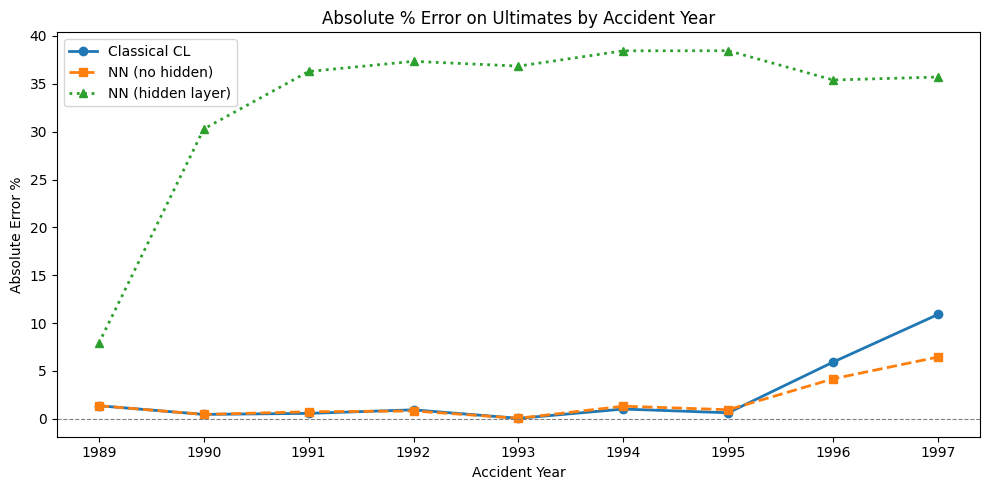

In [102]:
fig, ax = plt.subplots(figsize=(10, 5))
x = summary.index.astype(str)
ax.plot(x, summary["CL Error %"].abs(),          "o-",  label="Classical CL",      linewidth=2)
ax.plot(x, summary["Simple NN Error %"].abs(),   "s--", label="NN (no hidden)",     linewidth=2)
ax.plot(x, summary["Extended NN Error %"].abs(), "^:",  label="NN (hidden layer)",  linewidth=2)
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_title("Absolute % Error on Ultimates by Accident Year")
ax.set_xlabel("Accident Year")
ax.set_ylabel("Absolute Error %")
ax.legend()
plt.tight_layout()
plt.show()

---
## Summary

| Method | Description |
|--------|-------------|
| **Classical CL** | Volume-weighted link ratios applied to the latest diagonal |
| **NN (no hidden)** | Single-neuron linear network — *should match CL exactly* |
| **NN (hidden layer)** | Adds non-linearity — can learn patterns CL cannot |

**Key takeaway:** The Chain Ladder method is mathematically equivalent to training a neural network with one input, one output, no bias, and no activation function. This equivalence is the foundation for understanding how more complex architectures (LSTM, Transformer) extend actuarial intuition into sequential learning.

---

**Next — Module 2: DeepTriangle (Kuo 2019) — LSTM-based tail development**